# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [ ]:
print("So dong:", df.shape[0], "So cot:", df.shape[1])
df.info()

So dong: 541909 So cot: 8
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


## A.2. Missing values & Duplicate data

In [ ]:
print(df.isnull().sum())
print("So dong bi trung:", df.duplicated().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


So dong bi trung: 5268


## A.3. Invalid values

In [ ]:
print("Quantity <= 0:", (df['Quantity']<=0).sum())
print("UnitPrice <= 0:", (df['UnitPrice']<=0).sum())
print("CustomerID thieu:", df['CustomerID'].isnull().sum())

Quantity <= 0: 10624
UnitPrice <= 0: 2517
CustomerID thieu: 135080


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [ ]:
df_raw = df.copy()
df = df[(df['Quantity']>0) & (df['UnitPrice']>0)].copy()
df['Sales'] = df['Quantity'] * df['UnitPrice']
df[['Quantity','UnitPrice','Sales']].head()

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [ ]:
for col in ['Quantity','UnitPrice','Sales']:
    print(col, "- mean:", df[col].mean(), "median:", df[col].median(), "mode:", df[col].mode()[0])

Quantity - mean: 10.542037034242338 median: 3.0 mode: 1
UnitPrice - mean: 3.9076252471213193 median: 2.08 mode: 1.25
Sales - mean: 20.121871451639677 median: 9.9 mode: 15.0


## Group 2 — Dispersion

In [ ]:
for col in ['Quantity','UnitPrice','Sales']:
    s = df[col]
    print(col)
    print("Range:", s.max()-s.min())
    print("Std:", s.std())
    print("IQR:", s.quantile(0.75)-s.quantile(0.25))
    print("CV:", s.std()/s.mean())

Quantity
Range: 80994
Std: 155.52412351063626
IQR: 9.0
CV: 14.752758219826712
UnitPrice
Range: 13541.329
Std: 35.915681104255434
IQR: 2.88
CV: 9.191178486400123
Sales
Range: 168469.59900000002
Std: 270.35674321840673
IQR: 13.950000000000003
CV: 13.43596413823507


## Group 3 — Location and Shape

Skew: 506.70457814887453 Kurtosis: 297648.853558276


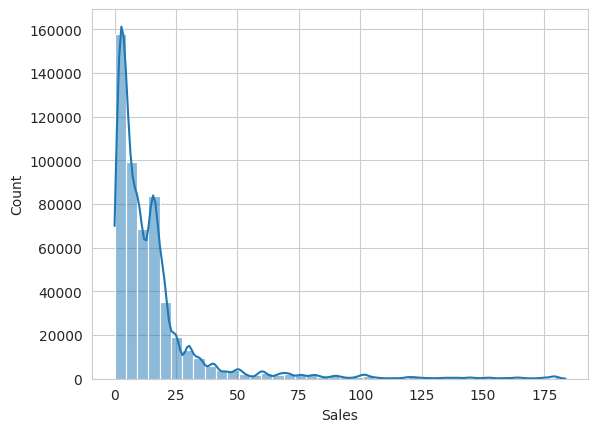

In [ ]:
s = df['Sales']
print("Skew:", stats.skew(s), "Kurtosis:", stats.kurtosis(s))

sns.histplot(df[df['Sales'] < df['Sales'].quantile(0.99)]['Sales'], bins=40, kde=True)
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [ ]:
sales_by_country = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
print(sales_by_country.head(10))
print("Ty le UK:", sales_by_country.iloc[0]/sales_by_country.sum()*100, "%")

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Sales, dtype: float64
Ty le UK: 84.61131522893568 %


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [ ]:
sales_by_product = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)
print(sales_by_product.head(10))

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Sales, dtype: float64


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

Month
1      691364.560
2      523631.890
3      717639.360
4      537808.621
5      770536.020
6      761739.900
7      719221.191
8      759138.380
9     1058590.172
10    1154979.300
11    1509496.330
12    1462538.820
Name: Sales, dtype: float64


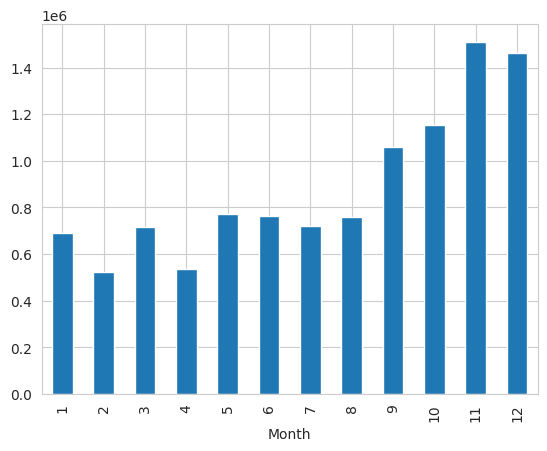

In [ ]:
df['Month'] = df['InvoiceDate'].dt.month
seasonality = df.groupby('Month')['Sales'].sum()
print(seasonality)

seasonality.plot(kind='bar')
plt.show()

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [ ]:
aov = df.groupby(['Country','InvoiceNo'])['Sales'].sum().groupby('Country').mean().sort_values(ascending=False)
print(aov)

Country
Singapore               3039.898571
Netherlands             3036.663191
Australia               2430.198421
Japan                   1969.282632
Lebanon                 1693.880000
Hong Kong               1426.527273
Brazil                  1143.600000
Sweden                  1066.064722
Switzerland             1057.220370
Denmark                 1053.074444
Israel                  1016.907500
Norway                  1004.595556
RSA                     1002.310000
EIRE                     984.215139
Greece                   952.104000
Cyprus                   849.398750
Channel Islands          786.555385
USA                      716.078000
Spain                    684.190111
United Arab Emirates     634.093333
Iceland                  615.714286
Canada                   611.063333
Austria                  599.922353
Portugal                 581.846552
Finland                  549.904390
Malta                    545.118000
France                   534.987526
United Kingdom      

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [ ]:
df_raw['is_return'] = df_raw['Quantity'] < 0
return_rate = df_raw.groupby('Country')['is_return'].mean().sort_values(ascending=False) * 100
print(return_rate.head(10))

Country
USA               38.487973
Czech Republic    16.666667
Malta             11.811024
Japan             10.335196
Saudi Arabia      10.000000
Australia          5.877681
Italy              5.603985
Bahrain            5.263158
Germany            4.770932
EIRE               3.684724
Name: is_return, dtype: float64


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*Insight:*

Dữ liệu gốc có 541909 dòng nhưng khá nhiều dòng thiếu CustomerID và có Quantity/UnitPrice âm hoặc bằng 0 (chủ yếu là đơn hủy), sau khi lọc còn khoảng 530 nghìn dòng để tính doanh thu. UK chiếm phần lớn doanh thu, khoảng 85% tổng doanh thu công ty — phụ thuộc khá nhiều vào 1 thị trường. Doanh thu tăng mạnh vào cuối năm, cao nhất là tháng 11, thấp nhất là tháng 2, nên có thể nói doanh số có mùa vụ. Giá trị đơn hàng trung bình ở vài nước nhỏ như Singapore, Netherlands lại cao hơn hẳn UK dù UK bán nhiều đơn hơn. Ngoài ra USA có tỷ lệ đơn bị hủy/trả hàng khá cao so với các nước khác, khoảng 38%, dù không phải thị trường lớn — có thể cần xem lại khâu vận chuyển/giao hàng ở đây.